In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme( style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 120

In [4]:
df = pd.read_csv(
"../data/final/ml_dataset.csv"
)

In [5]:
df.columns = (
df.columns
.str.strip()
.str.lower()
)

In [6]:
df["date"] = pd.to_datetime(
df["date"]
)

df = df.sort_values("date")

In [7]:
df.head(10)

,id,week_of_outbreak,state_ut,district,disease,cases,deaths,day,month,year,...,temp_change,precipitation_change,lai_change,spike_ratio,acceleration,growth_rate,outbreak_flag,outbreak_frequency_12m,log_cases,outbreak
8951,8705,27th week,West Bengal,South 24 Parganas,Cholera,51225.0,23,25,5,2009,...,-2.013333,0.486731,1.0,0.0,0.0,0.0,1,0.0,10.844002,1
5901,8768,31st week,Nagaland,Mokokchung,Malaria,124.0,9,4,5,2009,...,2.560000,0.133684,-10.0,0.0,0.0,0.0,1,0.0,4.828314,1
8810,8706,27th week,West Bengal,Purba Medinipur,Cholera,9689.0,0,5,5,2009,...,8.625000,-0.014208,-2.0,0.0,0.0,0.0,1,0.0,9.178850,1
6728,8678,26th week,Tamil Nadu,Ariyalur (Perambalur),Chikungunya,40.0,0,25,6,2009,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.713572,0
2832,8685,26th week,Karnataka,Bijapur,Acute Diarrhoeal Disease,200.0,0,9,6,2009,...,6.819000,0.470058,-1.0,0.0,-103.0,0.0,1,0.0,5.303305,1
8069,8683,26th week,Uttarakhand,Pithoragarh,Acute Diarrhoeal Disease,16.0,0,9,6,2009,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,2.833213,0
174,8669,26th week,Andhra Pradesh,Nellore,Acute Diarrhoeal Disease,43.0,0,27,6,2009,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.784190,0
2233,8658,25th week,Himachal Pradesh,Hamirpur,Acute Diarrhoeal Disease,33.0,0,18,6,2009,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.526361,0
6880,8694,27th week,Tamil Nadu,Krishnagiri,Chikungunya,5.0,0,30,6,2009,...,-3.331667,0.156184,0.0,0.0,0.0,0.0,0,0.0,1.791759,0
6407,8723,28th week,Punjab,Mohali,Cholera,412.0,0,16,6,2009,...,1.420000,0.000600,0.0,0.0,0.0,0.0,1,0.0,6.023448,1


In [8]:
TARGET = "outbreak"

In [9]:
REMOVE_COLS = [ "cases", "log_cases", "outbreak", "date", "id"]

In [10]:
FEATURES = [
col
for col in df.columns
if col not in REMOVE_COLS
]

FEATURES = [
col
for col in FEATURES
if pd.api.types.is_numeric_dtype(df[col])
]
print("TOTAL FEATURES")
print(len(FEATURES))

TOTAL FEATURES
29


In [11]:
#FEATURE MATRIX

X = df[FEATURES]
X = X.replace( [np.inf, -np.inf], np.nan )
X = X.fillna(0)
y = df[TARGET]
print(X.shape)

(8984, 29)


outbreak
0    6746
1    2238
Name: count, dtype: int64


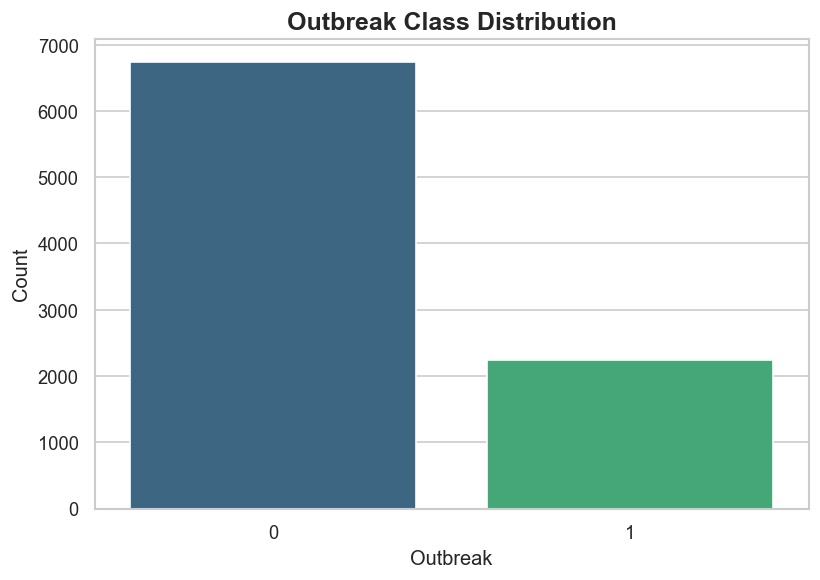

In [12]:
#CLASS DISTRIBUTION
class_counts = y.value_counts()
print(class_counts)
plt.figure(figsize=(7,5))
sns.countplot( x=y, palette="viridis" )

plt.title("Outbreak Class Distribution", fontsize=15, fontweight="bold" )

plt.xlabel("Outbreak")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(
"../reports/class_distribution.png",
bbox_inches="tight"
)
plt.show()

In [13]:
#SCALE POSITIVE WEIGHT

negative = class_counts[0]
positive = class_counts[1]
scale_pos_weight = negative / positive
print(f"Scale Positive Weight : {scale_pos_weight:.2f}")

Scale Positive Weight : 3.01


In [14]:
#TIME SERIES SPLIT

tscv = TimeSeriesSplit( n_splits=5 )

In [15]:
#MODEL

model = XGBClassifier( 
    n_estimators=400, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    objective="binary:logistic", 
    scale_pos_weight=scale_pos_weight, 
    eval_metric="logloss", 
    random_state=RANDOM_STATE )

In [16]:
#TRAINING LOOP
fold_results = []
all_probs = []
all_preds = []
all_actuals = []
threshold = 0.35
for fold, (train_idx, test_idx) in enumerate( tscv.split(X), start=1 ):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    
# Train
model.fit(
    X_train,
    y_train
)

# Probabilities
probs = model.predict_proba(X_test)[:,1]
# Threshold tuning
preds = ( probs >= threshold ).astype(int)

# Store values
all_probs.extend(probs) 
all_preds.extend(preds)
all_actuals.extend(y_test)

# Metrics
accuracy = accuracy_score( y_test, preds )
precision = precision_score( y_test, preds )

recall = recall_score( y_test, preds )
f1 = f1_score( y_test, preds )

fold_results.append({
    "fold": fold,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
})
print(f"FOLD {fold}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

FOLD 5
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [17]:
#RESULTS DATAFRAME
results_df = pd.DataFrame( fold_results )
results_df.style.background_gradient( cmap="Blues" )

,fold,accuracy,precision,recall,f1
0,5,1.000000,1.000000,1.000000,1.000000


In [18]:
#AVERAGE METRICS
avg_accuracy = results_df["accuracy"].mean()
avg_precision = results_df["precision"].mean()
avg_recall = results_df["recall"].mean()
avg_f1 = results_df["f1"].mean()
print("OUTBREAK CLASSIFIER PERFORMANCE")
print(f"Average Accuracy : {avg_accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall : {avg_recall:.4f}")
print(f"Average F1 Score : {avg_f1:.4f}")

OUTBREAK CLASSIFIER PERFORMANCE
Average Accuracy : 1.0000
Average Precision: 1.0000
Average Recall : 1.0000
Average F1 Score : 1.0000


In [20]:
#PERFORMANCE INTERPRETATION
if avg_recall < 0.5:
    print("⚠️ Low outbreak detection capability")

elif avg_recall < 0.75:
    print("✅ Moderate outbreak detection")

else:
    print("✅ Strong outbreak detection")

✅ Strong outbreak detection


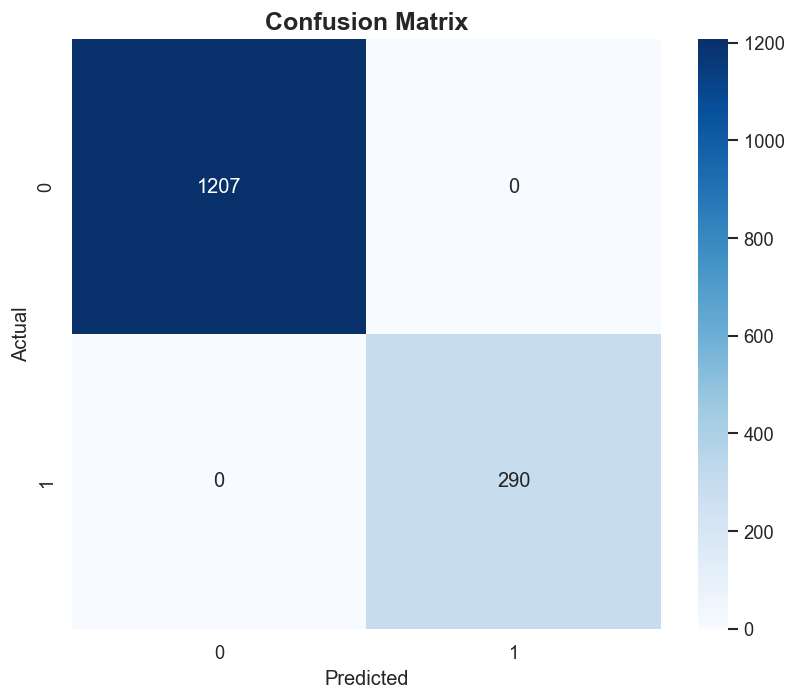

In [21]:
#CONFUSION MATRIX

cm = confusion_matrix( all_actuals, all_preds )
plt.figure(figsize=(7,6))
sns.heatmap( cm, annot=True, fmt="d",cmap="Blues" )

plt.title( "Confusion Matrix", fontsize=15, fontweight="bold" )
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(
"../reports/confusion_matrix.png",
bbox_inches="tight"
)
plt.show()

In [22]:
#CLASSIFICATION REPORT
report = classification_report( all_actuals, all_preds )
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1207
           1       1.00      1.00      1.00       290

    accuracy                           1.00      1497
   macro avg       1.00      1.00      1.00      1497
weighted avg       1.00      1.00      1.00      1497



In [23]:
#FEATURE IMPORTANCE
importance_df = pd.DataFrame({
"feature": FEATURES,
"importance": model.feature_importances_
})

importance_df = ( importance_df.sort_values(by="importance",ascending=False))
top_features = (importance_df.head(15))

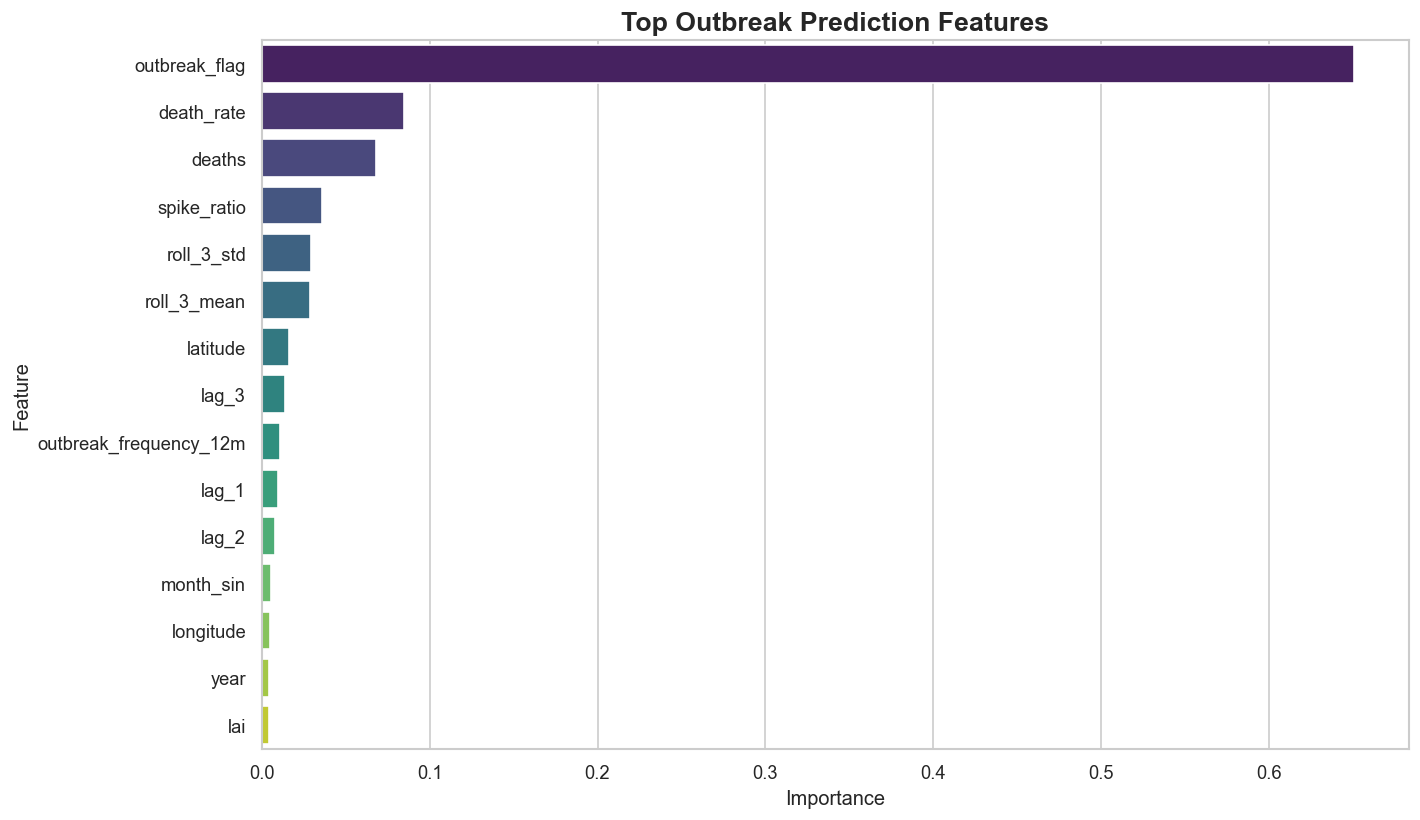

In [24]:
#FEATURE IMPORTANCE PLOT
plt.figure(figsize=(12,7))
sns.barplot(
data=top_features,x="importance", y="feature", palette="viridis")

plt.title("Top Outbreak Prediction Features",fontsize=16,fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
"../reports/classifier_feature_importance.png",
bbox_inches="tight"
)
plt.show()

In [25]:
#SAVE REPORTS
results_df.to_csv(
"../reports/classification_metrics.csv",
index=False
)
importance_df.to_csv(
"../reports/classifier_feature_importance.csv",
index=False
)
print(" Classification Reports Saved")

 Classification Reports Saved


In [27]:
#SAVE MODEL

os.makedirs("../artifacts",exist_ok=True)
joblib.dump(model,"../artifacts/xgb_classifier.pkl")
joblib.dump(threshold,"../artifacts/threshold.pkl")
print("Classifier Artifacts Saved")

Classifier Artifacts Saved


In [28]:
#SAVE EXPERIMENT
os.makedirs(
"../experiments/exp_03_classifier",
exist_ok=True
)
results_df.to_csv(
"../experiments/exp_03_classifier/fold_results.csv",
index=False
)
importance_df.to_csv(
"../experiments/exp_03_classifier/feature_importance.csv",
index=False
)
print(" Experiment Saved")

 Experiment Saved


In [30]:
#FINAL SUMMARY
summary_df = pd.DataFrame({
"Metric": [
    "Average Accuracy",
    "Average Precision",
    "Average Recall",
    "Average F1",
    "Threshold"
],
"Value": [
    round(avg_accuracy, 4),
    round(avg_precision, 4),
    round(avg_recall, 4),
    round(avg_f1, 4),
    threshold
]})
summary_df.style.background_gradient(cmap="Blues").hide(axis="index")

Metric,Value
Average Accuracy,1.000000
Average Precision,1.000000
Average Recall,1.000000
Average F1,1.000000
Threshold,0.350000
